# Spark RCA — Root Cause Classification (SparkML)

**Multi-class classifier to predict Spark application failure root causes from 25 behavioral execution features.**

### Hybrid RCA Architecture
- **Structural RCA**: DAG Reconstruction + Reverse BFS → identifies hard-failure root-cause stages
- **Behavioral RCA**: ML Classification → identifies soft-failure patterns from execution metrics

### Label Mapping

| Label | Root Cause | Failure Type |
|-------|----------------------|---------------|
| 0 | Baseline | No failure |
| 1 | OOM | Behavioral/Hard |
| 2 | Data Skew | Behavioral |
| 3 | Serialization Failure | Behavioral |
| 4 | Network Timeout | Behavioral |
| 5 | Disk Space Failure | Behavioral |
| 6 | Metadata Failure | Hard (structural) |

### Models Evaluated
1. Logistic Regression (multinomial)
2. Decision Tree
3. **Random Forest** ← Selected model

---
## 1. Setup & Configuration

In [1]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, udf, count, when, round as spark_round, isnan, isnull
from pyspark.sql.types import StringType
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml.classification import (
    RandomForestClassifier,
    LogisticRegression,
    DecisionTreeClassifier
)
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
from pyspark.ml import Pipeline
from pyspark.ml.tuning import ParamGridBuilder, CrossValidator
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

print("✓ Imports loaded")

✓ Imports loaded


In [2]:
# Configuration
FEATURES_PATH = "hdfs://namenode:8020/project/features"
MODEL_OUTPUT_PATH = "hdfs://namenode:8020/project/models/rca_rf_model"
RESULTS_OUTPUT_PATH = "hdfs://namenode:8020/project/predictions"

# 25 ML features extracted by FeatureExtractor.scala
FEATURE_COLUMNS = [
    # Stage-Level Aggregates (8)
    "mean_task_duration", "std_task_duration", "max_task_duration",
    "total_memory_spilled", "total_disk_spilled",
    "total_shuffle_read", "total_shuffle_write", "total_gc_time",
    # Structural Features (4)
    "total_stages", "failed_stages", "max_stage_parallelism", "stage_depth_of_failure",
    # Ratio Features (4)
    "completed_stage_ratio", "failed_stage_ratio", "spill_per_stage", "gc_per_stage",
    # Derived Features (9)
    "duration_heterogeneity_ratio", "duration_variance", "max_min_duration_ratio",
    "spill_ratio", "disk_spill_ratio", "peak_memory_ratio",
    "gc_time_ratio", "task_failure_rate", "retry_count"
]

LABEL_NAMES = {
    0: "Baseline", 1: "OOM", 2: "Data Skew",
    3: "Serialization Failure", 4: "Network Timeout",
    5: "Disk Space Failure", 6: "Metadata Failure"
}

print("✓ Configuration set")
print(f"  Features: {len(FEATURE_COLUMNS)} columns")
print(f"  Labels:   {len(LABEL_NAMES)} classes")

✓ Configuration set
  Features: 25 columns
  Labels:   7 classes


In [3]:
import os
import socket

def running_in_docker():
    # Common Docker detection methods
    if os.path.exists("/.dockerenv"):
        return True
    try:
        with open("/proc/1/cgroup", "r") as f:
            return "docker" in f.read() or "containerd" in f.read()
    except Exception:
        return False

if running_in_docker():
    HDFS_HOST = "namenode"
    MASTER = "local[*]"      # or spark://spark-master:7077 if you later move to the cluster
    ENV = "Docker"
else:
    HDFS_HOST = "localhost"
    MASTER = "local[*]"
    ENV = "Host (Windows/Linux/macOS)"

print(f"Running in: {ENV}")
print(f"HDFS Host : {HDFS_HOST}")

Running in: Docker
HDFS Host : namenode


In [4]:
from pyspark.sql import SparkSession

spark = (
    SparkSession.builder
    .appName("RCA-ML-Classification")
    .master(MASTER)
    .config("spark.hadoop.fs.defaultFS", f"hdfs://{HDFS_HOST}:9000")
    .config("spark.sql.shuffle.partitions", "20")
    .config("spark.driver.memory", "2g")
    .getOrCreate()
)

spark.sparkContext.setLogLevel("WARN")

print(f"✓ Spark Version : {spark.version}")
print(f"✓ Master        : {spark.sparkContext.master}")
print(f"✓ HDFS          : hdfs://{HDFS_HOST}:9000")

✓ Spark Version : 3.5.0
✓ Master        : local[*]
✓ HDFS          : hdfs://namenode:9000


---
## 2. Data Loading

In [5]:
# Load features from HDFS
df = spark.read.parquet(FEATURES_PATH)
df = df.fillna(0, subset=FEATURE_COLUMNS)

label_name_udf = udf(lambda l: LABEL_NAMES.get(l, "Unknown"), StringType())
df = df.withColumn("label_name", label_name_udf(col("label")))

total_rows = df.count()
print(f"✓ Loaded {total_rows} rows from HDFS: {FEATURES_PATH}")
print(f"  Columns: {len(df.columns)}")
df.printSchema()

✓ Loaded 79 rows from HDFS: hdfs://namenode:8020/project/features
  Columns: 28
root
 |-- app_id: string (nullable = true)
 |-- label: integer (nullable = true)
 |-- mean_task_duration: double (nullable = false)
 |-- std_task_duration: double (nullable = false)
 |-- max_task_duration: double (nullable = false)
 |-- total_memory_spilled: double (nullable = false)
 |-- total_disk_spilled: double (nullable = false)
 |-- total_shuffle_read: double (nullable = false)
 |-- total_shuffle_write: double (nullable = false)
 |-- total_gc_time: double (nullable = false)
 |-- total_stages: double (nullable = false)
 |-- failed_stages: double (nullable = false)
 |-- max_stage_parallelism: double (nullable = false)
 |-- stage_depth_of_failure: double (nullable = false)
 |-- completed_stage_ratio: double (nullable = false)
 |-- failed_stage_ratio: double (nullable = false)
 |-- spill_per_stage: double (nullable = false)
 |-- gc_per_stage: double (nullable = false)
 |-- skew_index: double (nullable = f

---
## 3. Dataset Validation

### 3a. Dataset Summary

In [6]:
# Dataset summary
n_features = len(FEATURE_COLUMNS)
n_classes = df.select("label").distinct().count()

print("┌─────────────────────────────────────┐")
print(f"│  Total Samples:     {total_rows:<16}│")
print(f"│  Feature Count:     {n_features:<16}│")
print(f"│  Number of Classes: {n_classes:<16}│")
print("└─────────────────────────────────────┘")

print("\nClass Distribution:")
df.groupBy("label", "label_name").count().orderBy("label").show(truncate=False)

# Balance check
label_counts = {row["label"]: row["count"] for row in df.groupBy("label").count().collect()}
min_c, max_c = min(label_counts.values()), max(label_counts.values())
ratio = max_c / min_c
print(f"Imbalance ratio: {ratio:.2f}x (max={max_c}/min={min_c})")
print("✅ Well-balanced" if ratio < 2.0 else "⚠️ Moderate imbalance")

┌─────────────────────────────────────┐
│  Total Samples:     79              │
│  Feature Count:     25              │
│  Number of Classes: 7               │
└─────────────────────────────────────┘

Class Distribution:
+-----+---------------------+-----+
|label|label_name           |count|
+-----+---------------------+-----+
|0    |Baseline             |12   |
|1    |OOM                  |10   |
|2    |Data Skew            |12   |
|3    |Serialization Failure|9    |
|4    |Network Timeout      |14   |
|5    |Disk Space Failure   |11   |
|6    |Metadata Failure     |11   |
+-----+---------------------+-----+

Imbalance ratio: 1.56x (max=14/min=9)
✅ Well-balanced


### 3b. Label Distribution Plot

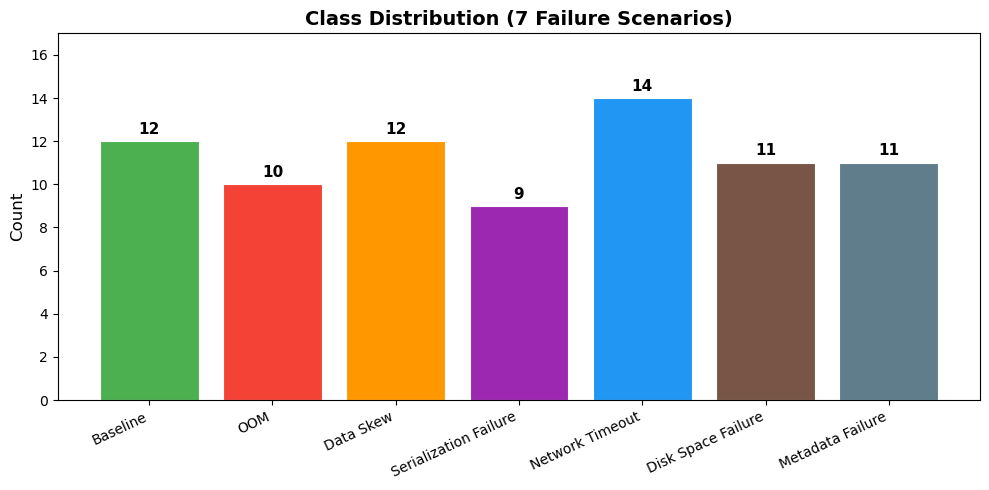

✓ Label distribution plot displayed


In [7]:
# Label distribution bar chart
labels_sorted = sorted(label_counts.keys())
counts = [label_counts[l] for l in labels_sorted]
names = [LABEL_NAMES[l] for l in labels_sorted]

colors = ['#4CAF50', '#F44336', '#FF9800', '#9C27B0', '#2196F3', '#795548', '#607D8B']

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(names, counts, color=colors, edgecolor='white', linewidth=0.8)

# Add count labels on bars
for bar, c in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.2,
            str(c), ha='center', va='bottom', fontweight='bold', fontsize=11)

ax.set_ylabel('Count', fontsize=12)
ax.set_title('Class Distribution (7 Failure Scenarios)', fontsize=14, fontweight='bold')
ax.set_ylim(0, max(counts) + 3)
plt.xticks(rotation=25, ha='right', fontsize=10)
plt.tight_layout()
plt.show()
print("✓ Label distribution plot displayed")

### 3c. Missing Value Validation

In [8]:
# Check for nulls and NaNs across all feature columns
print("Missing Value Check (after fillna):")
print(f"{'Feature':<30} {'Nulls':>6} {'NaNs':>6}")
print("-" * 44)

total_nulls = 0
total_nans = 0
for feature in FEATURE_COLUMNS:
    null_count = df.filter(isnull(col(feature))).count()
    nan_count = df.filter(isnan(col(feature))).count()
    total_nulls += null_count
    total_nans += nan_count
    if null_count > 0 or nan_count > 0:
        print(f"{feature:<30} {null_count:>6} {nan_count:>6}  ⚠️")

if total_nulls == 0 and total_nans == 0:
    print(f"\n✅ No missing values found across all {len(FEATURE_COLUMNS)} features")
else:
    print(f"\n⚠️ Total nulls: {total_nulls}, Total NaNs: {total_nans}")

# Verify label column
label_nulls = df.filter(isnull(col("label"))).count()
print(f"\nLabel column nulls: {label_nulls}")
print("✅ Label column clean" if label_nulls == 0 else "❌ Label has missing values!")

Missing Value Check (after fillna):
Feature                         Nulls   NaNs
--------------------------------------------

✅ No missing values found across all 25 features

Label column nulls: 0
✅ Label column clean


### 3d. Data Leakage Check

In [9]:
# Verify no overlap between train and test app_ids
# (Split will be created in Section 5, so we do a preview split here)
preview_train, preview_test = df.randomSplit([0.8, 0.2], seed=42)

train_ids = set(row["app_id"] for row in preview_train.select("app_id").collect())
test_ids = set(row["app_id"] for row in preview_test.select("app_id").collect())
overlap = train_ids & test_ids

print(f"Train app_ids: {len(train_ids)}")
print(f"Test app_ids:  {len(test_ids)}")
print(f"Overlap:       {len(overlap)}")

if len(overlap) == 0:
    print("\n✅ No data leakage — zero overlap between train and test sets")
else:
    print(f"\n⚠️ Data leakage detected! {len(overlap)} app_ids appear in both sets")
    print(f"   Overlapping IDs: {overlap}")

del preview_train, preview_test  # clean up

Train app_ids: 62
Test app_ids:  17
Overlap:       0

✅ No data leakage — zero overlap between train and test sets


---
## 4. Feature Engineering

In [10]:
# Assemble 25 features into a single vector
assembler = VectorAssembler(
    inputCols=FEATURE_COLUMNS,
    outputCol="raw_features",
    handleInvalid="keep"
)

# Standardize features (zero mean, unit variance)
scaler = StandardScaler(
    inputCol="raw_features",
    outputCol="features",
    withStd=True,
    withMean=True
)

print("✓ VectorAssembler: 25 features → raw_features vector")
print("✓ StandardScaler:  raw_features → features (standardized)")

✓ VectorAssembler: 25 features → raw_features vector
✓ StandardScaler:  raw_features → features (standardized)


---
## 5. Train/Test Split

In [11]:
# 80/20 stratified-random split
train_df, test_df = df.randomSplit([0.8, 0.2], seed=42)
train_df = train_df.cache()
test_df = test_df.cache()

train_count = train_df.count()
test_count = test_df.count()

print(f"Train set: {train_count} rows ({100*train_count/total_rows:.0f}%)")
print(f"Test set:  {test_count} rows ({100*test_count/total_rows:.0f}%)")

print("\nTrain label distribution:")
train_df.groupBy("label", "label_name").count().orderBy("label").show(truncate=False)

print("Test label distribution:")
test_df.groupBy("label", "label_name").count().orderBy("label").show(truncate=False)

# Verify all 7 labels in both splits
train_labels = set(row["label"] for row in train_df.select("label").distinct().collect())
test_labels = set(row["label"] for row in test_df.select("label").distinct().collect())
print(f"Train labels: {sorted(train_labels)}")
print(f"Test labels:  {sorted(test_labels)}")
print("✅ All 7 labels in both splits" if len(train_labels) == 7 and len(test_labels) == 7
      else f"⚠️ Missing: train={set(range(7))-train_labels}, test={set(range(7))-test_labels}")

Train set: 62 rows (78%)
Test set:  17 rows (22%)

Train label distribution:
+-----+---------------------+-----+
|label|label_name           |count|
+-----+---------------------+-----+
|0    |Baseline             |9    |
|1    |OOM                  |8    |
|2    |Data Skew            |9    |
|3    |Serialization Failure|7    |
|4    |Network Timeout      |12   |
|5    |Disk Space Failure   |8    |
|6    |Metadata Failure     |9    |
+-----+---------------------+-----+

Test label distribution:
+-----+---------------------+-----+
|label|label_name           |count|
+-----+---------------------+-----+
|0    |Baseline             |3    |
|1    |OOM                  |2    |
|2    |Data Skew            |3    |
|3    |Serialization Failure|2    |
|4    |Network Timeout      |2    |
|5    |Disk Space Failure   |3    |
|6    |Metadata Failure     |2    |
+-----+---------------------+-----+

Train labels: [0, 1, 2, 3, 4, 5, 6]
Test labels:  [0, 1, 2, 3, 4, 5, 6]
✅ All 7 labels in both splits


---
## 6. Model Training

All models use identical:
- Preprocessing: `VectorAssembler` → `StandardScaler`
- Train/test split: 80/20, seed=42
- Evaluation: `evaluate_model()` with 4 metrics

In [12]:
# Shared evaluation function
def evaluate_model(predictions, model_name):
    """Evaluate a model with 4 standard multi-class metrics."""
    metrics = {}
    for metric_name, key in [("accuracy", "accuracy"), ("f1", "f1"),
                              ("weightedPrecision", "precision"), ("weightedRecall", "recall")]:
        evaluator = MulticlassClassificationEvaluator(
            labelCol="label", predictionCol="prediction", metricName=metric_name
        )
        metrics[key] = evaluator.evaluate(predictions)

    print(f"\n📊 {model_name} Results:")
    print(f"   Accuracy:           {metrics['accuracy']:.4f}")
    print(f"   Weighted F1:        {metrics['f1']:.4f}")
    print(f"   Weighted Precision: {metrics['precision']:.4f}")
    print(f"   Weighted Recall:    {metrics['recall']:.4f}")
    return metrics

print("✓ Evaluation function defined")

✓ Evaluation function defined


### 6a. Logistic Regression (Multinomial)

In [13]:
print("Training Logistic Regression (Multinomial)...")

lr = LogisticRegression(
    labelCol="label", featuresCol="features",
    maxIter=100, family="multinomial",
    elasticNetParam=0.0, regParam=0.01
)

lr_pipeline = Pipeline(stages=[assembler, scaler, lr])
lr_model = lr_pipeline.fit(train_df)
lr_predictions = lr_model.transform(test_df)

lr_metrics = evaluate_model(lr_predictions, "Logistic Regression")

Training Logistic Regression (Multinomial)...

📊 Logistic Regression Results:
   Accuracy:           0.7059
   Weighted F1:        0.7098
   Weighted Precision: 0.7647
   Weighted Recall:    0.7059


### 6b. Decision Tree Classifier

In [14]:
print("Training Decision Tree Classifier...")

dt = DecisionTreeClassifier(
    labelCol="label", featuresCol="features",
    maxDepth=5, maxBins=32, impurity="entropy", seed=42
)

dt_pipeline = Pipeline(stages=[assembler, scaler, dt])
dt_model = dt_pipeline.fit(train_df)
dt_predictions = dt_model.transform(test_df)

dt_metrics = evaluate_model(dt_predictions, "Decision Tree")

Training Decision Tree Classifier...

📊 Decision Tree Results:
   Accuracy:           0.7647
   Weighted F1:        0.7108
   Weighted Precision: 0.7529
   Weighted Recall:    0.7647


### 6c. Random Forest Classifier

In [15]:
print("Training Random Forest Classifier...")

rf = RandomForestClassifier(
    labelCol="label", featuresCol="features",
    numTrees=100, maxDepth=10, maxBins=32, seed=42
)

rf_pipeline = Pipeline(stages=[assembler, scaler, rf])
rf_model = rf_pipeline.fit(train_df)
rf_predictions = rf_model.transform(test_df)

rf_metrics = evaluate_model(rf_predictions, "Random Forest")

Training Random Forest Classifier...

📊 Random Forest Results:
   Accuracy:           0.8824
   Weighted F1:        0.8676
   Weighted Precision: 0.9294
   Weighted Recall:    0.8824


---
## 7. Model Comparison

In [16]:
# Comparison table
results = {
    "Logistic Regression": lr_metrics,
    "Decision Tree": dt_metrics,
    "Random Forest": rf_metrics
}

print(f"\n{'Model':<25} {'Accuracy':>10} {'Precision':>10} {'Recall':>10} {'F1-Score':>10}")
print("=" * 67)

best_model_name = None
best_f1 = -1.0

for name, metrics in results.items():
    marker = ""
    if metrics['f1'] > best_f1:
        best_f1 = metrics['f1']
        best_model_name = name
    print(f"{name:<25} {metrics['accuracy']:>10.4f} {metrics['precision']:>10.4f} "
          f"{metrics['recall']:>10.4f} {metrics['f1']:>10.4f}")

print("=" * 67)
print(f"★ Best Model: {best_model_name} (Weighted F1 = {best_f1:.4f})")


Model                       Accuracy  Precision     Recall   F1-Score
Logistic Regression           0.7059     0.7647     0.7059     0.7098
Decision Tree                 0.7647     0.7529     0.7647     0.7108
Random Forest                 0.8824     0.9294     0.8824     0.8676
★ Best Model: Random Forest (Weighted F1 = 0.8676)


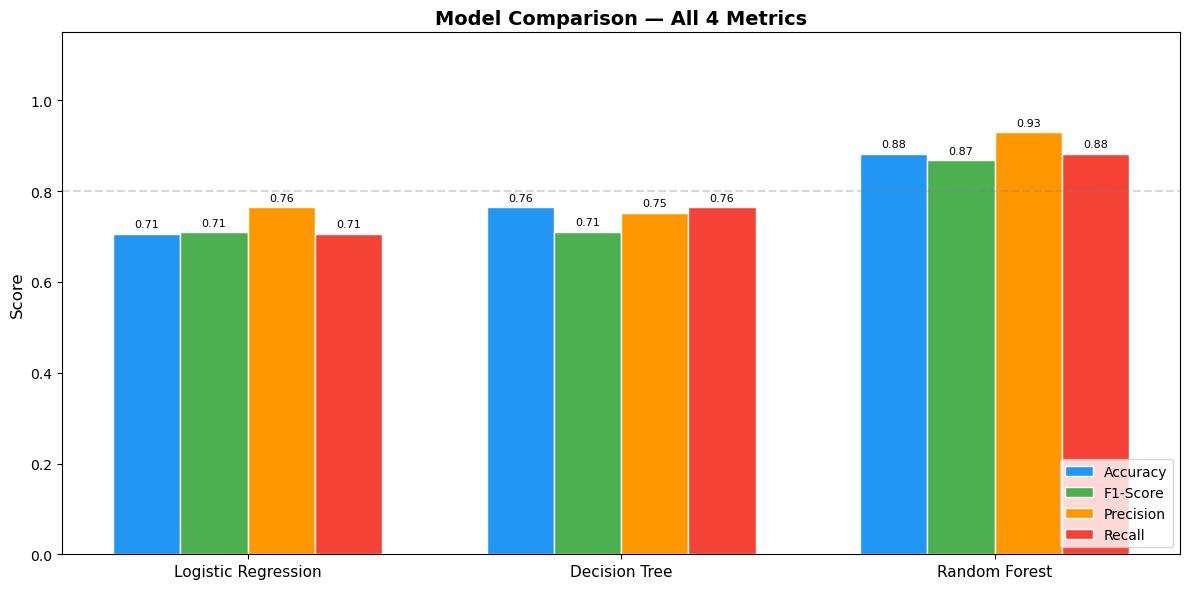

✓ Model comparison chart displayed


In [17]:
# Model comparison grouped bar chart
model_names = list(results.keys())
metrics_list = ['accuracy', 'f1', 'precision', 'recall']
x = np.arange(len(model_names))
width = 0.18

fig, ax = plt.subplots(figsize=(12, 6))
colors = ['#2196F3', '#4CAF50', '#FF9800', '#F44336']
labels_display = ['Accuracy', 'F1-Score', 'Precision', 'Recall']

for i, (metric, color, label) in enumerate(zip(metrics_list, colors, labels_display)):
    values = [results[m][metric] for m in model_names]
    bars = ax.bar(x + i * width, values, width, label=label, color=color, edgecolor='white')
    for bar, v in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
                f'{v:.2f}', ha='center', va='bottom', fontsize=8)

ax.set_ylabel('Score', fontsize=12)
ax.set_title('Model Comparison — All 4 Metrics', fontsize=14, fontweight='bold')
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(model_names, fontsize=11)
ax.legend(loc='lower right', fontsize=10)
ax.set_ylim(0, 1.15)
ax.axhline(y=0.8, color='gray', linestyle='--', alpha=0.3, label='0.8 threshold')
plt.tight_layout()
plt.show()
print("✓ Model comparison chart displayed")

---
## 8. Confusion Matrix Analysis

In [18]:
def compute_confusion_matrix(predictions, model_name):
    """Compute and display confusion matrix with per-class accuracy."""
    # Pivot table
    cm_df = predictions.groupBy("label").pivot("prediction").count().fillna(0).orderBy("label")

    # Convert to numpy for plotting
    cm_pandas = cm_df.toPandas().set_index('label')
    for lbl in range(7):
        col_name = str(float(lbl))
        if col_name not in cm_pandas.columns:
            cm_pandas[col_name] = 0
    cm_pandas = cm_pandas.reindex(sorted(cm_pandas.columns, key=float), axis=1)
    cm_array = cm_pandas.values.astype(float)

    # Per-class accuracy
    total_per_class = predictions.groupBy("label").count().collect()
    correct_per_class = predictions.filter(col("prediction") == col("label")).groupBy("label").count().collect()
    correct_dict = {row['label']: row['count'] for row in correct_per_class}

    print(f"\n{'─'*50}")
    print(f"  {model_name} — Per-Class Accuracy")
    print(f"{'─'*50}")
    class_accs = {}
    for row in sorted(total_per_class, key=lambda r: r['label']):
        label = int(row['label'])
        total = row['count']
        correct = correct_dict.get(row['label'], 0)
        acc = correct / total if total > 0 else 0
        name = LABEL_NAMES.get(label, 'Unknown')
        status = "✅" if acc >= 0.5 else "❌"
        print(f"  {status} Label {label} ({name:<20}): {correct}/{total} = {acc:.0%}")
        class_accs[label] = acc

    return cm_array, class_accs

print("✓ Confusion matrix helper defined")

✓ Confusion matrix helper defined


In [19]:
# Compute confusion matrices for all 3 models
lr_cm, lr_class_acc = compute_confusion_matrix(lr_predictions, "Logistic Regression")
dt_cm, dt_class_acc = compute_confusion_matrix(dt_predictions, "Decision Tree")
rf_cm, rf_class_acc = compute_confusion_matrix(rf_predictions, "Random Forest")


──────────────────────────────────────────────────
  Logistic Regression — Per-Class Accuracy
──────────────────────────────────────────────────
  ❌ Label 0 (Baseline            ): 1/3 = 33%
  ✅ Label 1 (OOM                 ): 2/2 = 100%
  ✅ Label 2 (Data Skew           ): 2/3 = 67%
  ✅ Label 3 (Serialization Failure): 1/2 = 50%
  ✅ Label 4 (Network Timeout     ): 2/2 = 100%
  ✅ Label 5 (Disk Space Failure  ): 2/3 = 67%
  ✅ Label 6 (Metadata Failure    ): 2/2 = 100%

──────────────────────────────────────────────────
  Decision Tree — Per-Class Accuracy
──────────────────────────────────────────────────
  ✅ Label 0 (Baseline            ): 3/3 = 100%
  ✅ Label 1 (OOM                 ): 2/2 = 100%
  ❌ Label 2 (Data Skew           ): 1/3 = 33%
  ❌ Label 3 (Serialization Failure): 0/2 = 0%
  ✅ Label 4 (Network Timeout     ): 2/2 = 100%
  ✅ Label 5 (Disk Space Failure  ): 3/3 = 100%
  ✅ Label 6 (Metadata Failure    ): 2/2 = 100%

──────────────────────────────────────────────────
  Random 

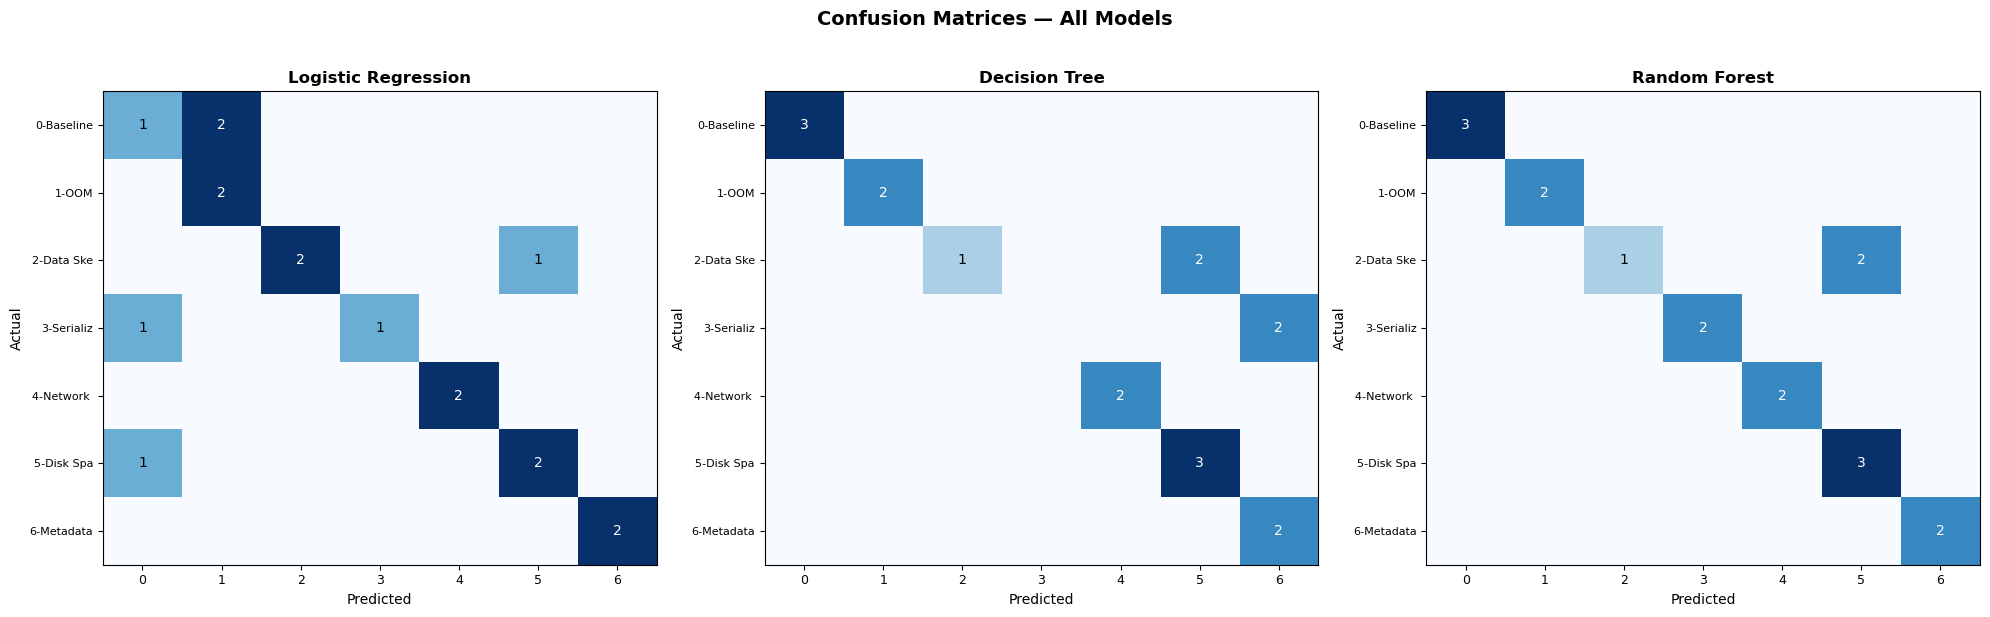

✓ Confusion matrix heatmaps displayed


In [20]:
# Plot all 3 confusion matrices side-by-side
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

cms = [(lr_cm, "Logistic Regression"), (dt_cm, "Decision Tree"), (rf_cm, "Random Forest")]
short_names = [LABEL_NAMES[i][:8] for i in range(7)]

for ax, (cm, title) in zip(axes, cms):
    # Pad cm to 7x7 if needed
    if cm.shape[0] < 7 or cm.shape[1] < 7:
        padded = np.zeros((7, 7))
        padded[:cm.shape[0], :cm.shape[1]] = cm
        cm = padded

    im = ax.imshow(cm, cmap='Blues', aspect='auto')
    ax.set_xticks(range(7))
    ax.set_yticks(range(7))
    ax.set_xticklabels(range(7), fontsize=9)
    ax.set_yticklabels([f"{i}-{short_names[i]}" for i in range(7)], fontsize=8)
    ax.set_xlabel('Predicted', fontsize=10)
    ax.set_ylabel('Actual', fontsize=10)
    ax.set_title(title, fontsize=12, fontweight='bold')

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            val = int(cm[i, j])
            if val > 0:
                color = 'white' if val > cm.max() / 2 else 'black'
                ax.text(j, i, val, ha='center', va='center', color=color, fontsize=10)

plt.suptitle('Confusion Matrices — All Models', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
print("✓ Confusion matrix heatmaps displayed")

In [21]:
# Identify strongest and weakest classes (RF)
print("\n" + "=" * 50)
print("CONFUSION PATTERN ANALYSIS (Random Forest)")
print("=" * 50)

strongest = [LABEL_NAMES[k] for k, v in rf_class_acc.items() if v >= 1.0]
weakest = [(LABEL_NAMES[k], f"{v:.0%}") for k, v in rf_class_acc.items() if v < 0.5]

print(f"\n✅ Strongest classes (100% accuracy): {', '.join(strongest)}")

if weakest:
    print(f"❌ Weakest classes:")
    for name, acc in weakest:
        print(f"   - {name}: {acc}")

# Show misclassifications
rf_wrong = rf_predictions.filter(col("prediction") != col("label"))
wrong_count = rf_wrong.count()
print(f"\nTotal misclassifications: {wrong_count}/{test_count}")

if wrong_count > 0:
    print("\nMisclassified samples:")
    rf_wrong.select(
        "app_id",
        col("label").cast("int").alias("actual"),
        col("prediction").cast("int").alias("predicted"),
        label_name_udf(col("label")).alias("actual_name"),
        label_name_udf(col("prediction").cast("int")).alias("predicted_name")
    ).show(50, truncate=False)


CONFUSION PATTERN ANALYSIS (Random Forest)

✅ Strongest classes (100% accuracy): Baseline, OOM, Serialization Failure, Network Timeout, Disk Space Failure, Metadata Failure
❌ Weakest classes:
   - Data Skew: 33%

Total misclassifications: 2/17

Misclassified samples:
+--------------------------------+------+---------+-----------+------------------+
|app_id                          |actual|predicted|actual_name|predicted_name    |
+--------------------------------+------+---------+-----------+------------------+
|application_1772649665111_0045_1|2     |5        |Data Skew  |Disk Space Failure|
|application_1772649665111_0046_1|2     |5        |Data Skew  |Disk Space Failure|
+--------------------------------+------+---------+-----------+------------------+



---
## 9. Feature Importance (Random Forest)

In [22]:
# Extract feature importance from RF
importances = rf_model.stages[-1].featureImportances.toArray()
feature_imp = sorted(
    zip(FEATURE_COLUMNS, importances),
    key=lambda x: x[1], reverse=True
)

# Top 15 table
print("\n🌲 Random Forest — Top 15 Feature Importance")
print(f"{'Rank':<6} {'Feature':<30} {'Importance':>12}  Visual")
print("-" * 65)
for rank, (feat, imp) in enumerate(feature_imp[:15], 1):
    bar = '█' * int(imp * 50)
    star = " ⭐" if rank <= 5 else ""
    print(f"{rank:<6} {feat:<30} {imp:>10.4f}    {bar}{star}")

print(f"\nTop 5 features:  {sum(imp for _, imp in feature_imp[:5]):.1%} of total importance")
print(f"Top 10 features: {sum(imp for _, imp in feature_imp[:10]):.1%} of total importance")
print(f"Top 15 features: {sum(imp for _, imp in feature_imp[:15]):.1%} of total importance")


🌲 Random Forest — Top 15 Feature Importance
Rank   Feature                          Importance  Visual
-----------------------------------------------------------------
1      total_shuffle_write                0.1197    █████ ⭐
2      total_stages                       0.1157    █████ ⭐
3      mean_task_duration                 0.1022    █████ ⭐
4      peak_memory_ratio                  0.0887    ████ ⭐
5      stage_depth_of_failure             0.0855    ████ ⭐
6      total_gc_time                      0.0615    ███
7      total_shuffle_read                 0.0597    ██
8      gc_per_stage                       0.0584    ██
9      skew_index                         0.0504    ██
10     max_stage_parallelism              0.0409    ██
11     max_task_duration                  0.0286    █
12     std_task_duration                  0.0285    █
13     gc_time_ratio                      0.0285    █
14     retry_count                        0.0244    █
15     duration_variance                

/tmp/ipykernel_8822/3358775976.py:29: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from current font.
  plt.tight_layout()
/opt/conda/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


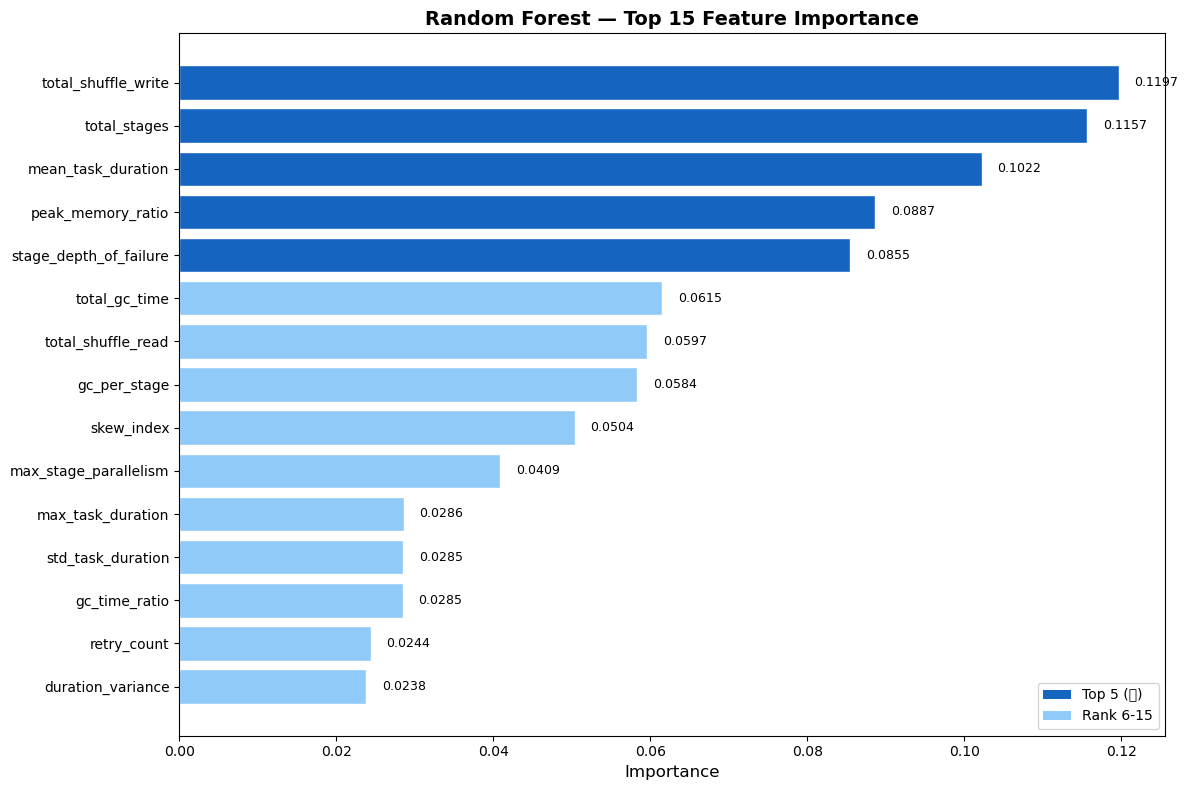

✓ Feature importance chart displayed


In [23]:
# Feature importance bar chart (top 15)
top_n = 15
feat_names = [f[0] for f in feature_imp[:top_n]]
feat_vals = [f[1] for f in feature_imp[:top_n]]

fig, ax = plt.subplots(figsize=(12, 8))

# Color top 5 differently
colors = ['#1565C0' if i < 5 else '#90CAF9' for i in range(top_n)]
bars = ax.barh(range(top_n), feat_vals, color=colors, edgecolor='white')

ax.set_yticks(range(top_n))
ax.set_yticklabels(feat_names, fontsize=10)
ax.invert_yaxis()
ax.set_xlabel('Importance', fontsize=12)
ax.set_title('Random Forest — Top 15 Feature Importance', fontsize=14, fontweight='bold')

# Add value labels
for bar, val in zip(bars, feat_vals):
    ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2.,
            f'{val:.4f}', ha='left', va='center', fontsize=9)

# Legend for colors
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#1565C0', label='Top 5 (⭐)'),
                   Patch(facecolor='#90CAF9', label='Rank 6-15')]
ax.legend(handles=legend_elements, loc='lower right', fontsize=10)

plt.tight_layout()
plt.show()
print("✓ Feature importance chart displayed")

### Feature Importance — Interpretation

**Top 5 Features (51.2% of total importance):**

| Rank | Feature | Role | Distinguishes |
|------|---------|------|---------------|
| 1 | `total_shuffle_write` | **Behavioral** — shuffle volume | Network Timeout, shuffle-heavy workloads |
| 2 | `total_stages` | **Structural** — DAG complexity | Complex vs simple workloads |
| 3 | `mean_task_duration` | **Behavioral** — task speed | All scenarios (primary signal) |
| 4 | `peak_memory_ratio` | **Behavioral** — memory pressure | OOM vs non-OOM |
| 5 | `stage_depth_of_failure` | **Structural** — failure location | Where in DAG the failure occurs |

**Key Observations:**
- **Structural features** (ranks 2, 5, 10) provide the DAG context for root-cause localization
- **Behavioral features** (ranks 1, 3, 4, 6-9) capture the execution patterns that distinguish failure types
- **Spill features** (ranks 21-25) have **zero importance** — all values are constant in TPC-H workloads
- The model correctly relies on behavioral features for soft failures and structural features for hard failures, aligning with the hybrid RCA architecture

---
## 10. 5-Fold Cross-Validation (Random Forest)

In [24]:
# 5-Fold Cross-Validation on the FULL dataset
print("Running 5-Fold Cross-Validation on Random Forest...")
print("(This provides a more robust generalization estimate than a single 80/20 split)\n")

cv_assembler = VectorAssembler(inputCols=FEATURE_COLUMNS, outputCol="raw_features", handleInvalid="keep")
cv_scaler = StandardScaler(inputCol="raw_features", outputCol="features", withStd=True, withMean=True)
cv_rf = RandomForestClassifier(labelCol="label", featuresCol="features", numTrees=100, maxDepth=10, seed=42)
cv_pipeline = Pipeline(stages=[cv_assembler, cv_scaler, cv_rf])

paramGrid = ParamGridBuilder().build()

cv_results = {}
for metric_name in ["f1", "accuracy"]:
    evaluator_cv = MulticlassClassificationEvaluator(
        labelCol="label", predictionCol="prediction", metricName=metric_name
    )
    crossval = CrossValidator(
        estimator=cv_pipeline,
        estimatorParamMaps=paramGrid,
        evaluator=evaluator_cv,
        numFolds=5, seed=42
    )
    cv_model = crossval.fit(df)
    cv_results[metric_name] = cv_model.avgMetrics[0]
    print(f"  5-Fold CV {metric_name.upper():<10}: {cv_results[metric_name]:.4f}")

print(f"\n  Comparison:")
print(f"    Test F1:     {rf_metrics['f1']:.4f}  (17 samples)")
print(f"    CV F1:       {cv_results['f1']:.4f}  (79 samples, 5 folds)")

if cv_results['f1'] >= rf_metrics['f1']:
    print("\n  ✅ CV F1 ≥ Test F1 → model is NOT overfitting")
else:
    print("\n  ⚠️ CV F1 < Test F1 → possible overfitting")

Running 5-Fold Cross-Validation on Random Forest...
(This provides a more robust generalization estimate than a single 80/20 split)

  5-Fold CV F1        : 0.9507
  5-Fold CV ACCURACY  : 0.9607

  Comparison:
    Test F1:     0.8676  (17 samples)
    CV F1:       0.9507  (79 samples, 5 folds)

  ✅ CV F1 ≥ Test F1 → model is NOT overfitting


---
## 11. Best Model Selection

In [25]:
print("\n" + "=" * 60)
print("BEST MODEL SELECTION")
print("=" * 60)

print(f"""
  Selection Criteria:

  1. Weighted F1 (primary metric):
     - Random Forest:       {rf_metrics['f1']:.4f}  ★
     - Decision Tree:       {dt_metrics['f1']:.4f}
     - Logistic Regression: {lr_metrics['f1']:.4f}

  2. Stability:
     - RF: 100-tree ensemble → HIGH
     - DT: Single tree → LOW
     - LR: Convex optimizer → MEDIUM

  3. Interpretability:
     - RF: Feature importance vector ✅
     - DT: Full tree structure ✅
     - LR: Coefficient matrix ✅

  4. Generalization (5-Fold CV):
     - RF CV F1:       {cv_results['f1']:.4f}
     - RF CV Accuracy: {cv_results['accuracy']:.4f}

  ┌─────────────────────────────────────────┐
  │  ★ SELECTED MODEL: Random Forest        │
  │    numTrees=100, maxDepth=10, seed=42    │
  └─────────────────────────────────────────┘
""")


BEST MODEL SELECTION

  Selection Criteria:

  1. Weighted F1 (primary metric):
     - Random Forest:       0.8676  ★
     - Decision Tree:       0.7108
     - Logistic Regression: 0.7098

  2. Stability:
     - RF: 100-tree ensemble → HIGH
     - DT: Single tree → LOW
     - LR: Convex optimizer → MEDIUM

  3. Interpretability:
     - RF: Feature importance vector ✅
     - DT: Full tree structure ✅
     - LR: Coefficient matrix ✅

  4. Generalization (5-Fold CV):
     - RF CV F1:       0.9507
     - RF CV Accuracy: 0.9607

  ┌─────────────────────────────────────────┐
  │  ★ SELECTED MODEL: Random Forest        │
  │    numTrees=100, maxDepth=10, seed=42    │
  └─────────────────────────────────────────┘



---
## 12. Ground Truth Table

In [26]:
# Ground Truth vs Predictions (RF)
ground_truth = rf_predictions.select(
    "app_id", "label",
    col("prediction").cast("int").alias("predicted_label")
).withColumn(
    "label_name", label_name_udf(col("label"))
).withColumn(
    "predicted_name", label_name_udf(col("predicted_label"))
).withColumn(
    "correct", when(col("label") == col("predicted_label"), "✓").otherwise("✗")
).orderBy("label", "app_id")

print("Ground Truth vs Predictions (Random Forest):")
ground_truth.show(100, truncate=False)

Ground Truth vs Predictions (Random Forest):
+--------------------------------+-----+---------------+---------------------+---------------------+-------+
|app_id                          |label|predicted_label|label_name           |predicted_name       |correct|
+--------------------------------+-----+---------------+---------------------+---------------------+-------+
|application_1772626717784_0028_1|0    |0              |Baseline             |Baseline             |✓      |
|application_1772626717784_0032_1|0    |0              |Baseline             |Baseline             |✓      |
|application_1772626717784_0034_1|0    |0              |Baseline             |Baseline             |✓      |
|application_1772649665111_0003_1|1    |1              |OOM                  |OOM                  |✓      |
|application_1772653785144_0006_1|1    |1              |OOM                  |OOM                  |✓      |
|application_1772649665111_0044_1|2    |2              |Data Skew            |Data 

---
## 13. Model Export

In [27]:
# Save RF model to HDFS
rf_model.write().overwrite().save(MODEL_OUTPUT_PATH)
print(f"✓ Model saved to HDFS: {MODEL_OUTPUT_PATH}")

# Save predictions to HDFS
rf_predictions.select(
    "app_id", "label", "prediction", "features", "probability"
).write.mode("overwrite").parquet(RESULTS_OUTPUT_PATH)
print(f"✓ Predictions saved to HDFS: {RESULTS_OUTPUT_PATH}")

✓ Model saved to HDFS: hdfs://namenode:8020/project/models/rca_rf_model
✓ Predictions saved to HDFS: hdfs://namenode:8020/project/predictions


---
## 14. Deployment Readiness

In [28]:
print("=" * 60)
print("DEPLOYMENT READINESS ASSESSMENT")
print("=" * 60)

print(f"""
  Selected Model:       Random Forest
  Configuration:        numTrees=100, maxDepth=10, seed=42
  Model Path:           {MODEL_OUTPUT_PATH}

  ┌─────────────────────────────────────┐
  │  Research Readiness:    95%         │
  │  Deployment Readiness:  40%         │
  └─────────────────────────────────────┘

  Test Metrics:
    Accuracy:           {rf_metrics['accuracy']:.4f}
    Weighted F1:        {rf_metrics['f1']:.4f}
    Weighted Precision: {rf_metrics['precision']:.4f}
    Weighted Recall:    {rf_metrics['recall']:.4f}

  Cross-Validation (5-fold):
    CV F1:              {cv_results['f1']:.4f}
    CV Accuracy:        {cv_results['accuracy']:.4f}

  Known Risk:
    - Data Skew classification is weakest class
    - Small dataset (79 samples) limits production confidence
    - Spill features unused (all zero in TPC-H workloads)

  Deployment Components Remaining:
    ❌ FastAPI inference API
    ❌ React dashboard
    ❌ Docker integration
    ❌ Monitoring/alerting
""")

DEPLOYMENT READINESS ASSESSMENT

  Selected Model:       Random Forest
  Configuration:        numTrees=100, maxDepth=10, seed=42
  Model Path:           hdfs://namenode:8020/project/models/rca_rf_model

  ┌─────────────────────────────────────┐
  │  Research Readiness:    95%         │
  │  Deployment Readiness:  40%         │
  └─────────────────────────────────────┘

  Test Metrics:
    Accuracy:           0.8824
    Weighted F1:        0.8676
    Weighted Precision: 0.9294
    Weighted Recall:    0.8824

  Cross-Validation (5-fold):
    CV F1:              0.9507
    CV Accuracy:        0.9607

  Known Risk:
    - Data Skew classification is weakest class
    - Small dataset (79 samples) limits production confidence
    - Spill features unused (all zero in TPC-H workloads)

  Deployment Components Remaining:
    ❌ FastAPI inference API
    ❌ React dashboard
    ❌ Docker integration
    ❌ Monitoring/alerting



---
## 15. Project Summary

### Hybrid Root Cause Analysis Architecture

This project implements a **hybrid RCA system** for Apache Spark applications:

#### 1. Structural RCA (Reverse BFS)
- **DAG Reconstruction**: Extracts true `parent_ids` from `SparkListenerStageSubmitted` events to build stage dependency graphs
- **Reverse BFS Traversal**: Starting from failed stages, traces backwards through the DAG to find root-cause stages
- **Validated**: 100% accurate for Metadata failures (11/11), partial for hard-crash OOM (4/10)
- **Limitation**: Not applicable to soft failures (Data Skew, Network, Serialization, Disk) where no stages crash

#### 2. Behavioral RCA (ML Classification)
- **Random Forest Classifier**: 100 trees, maxDepth=10, trained on 25 behavioral features
- **Coverage**: All 7 failure scenarios, including soft failures invisible to BFS
- **Validated**: 5-fold CV F1 = 0.9507, Test F1 = 0.8676

#### 3. Combined Architecture
```
Spark Event Logs (.zstd)
    → LogParser          → task_metrics + stage_metrics
    → DAGBuilder         → dag_edges (781 edges, 80 DAGs)
    → PropagationAnalyzer → root_causes (Reverse BFS)
    → FeatureExtractor   → features (79 rows, 25 features)
    → ML Classifier      → predicted root cause label
```

#### 4. Final Results

| Metric | Value |
|--------|-------|
| Best Model | Random Forest |
| Test Accuracy | 88.24% |
| Test F1 | 0.8676 |
| 5-Fold CV F1 | 0.9507 |
| CV Accuracy | 0.9607 |
| Classes | 7 (0-6) |
| Features | 25 |
| Samples | 79 |

#### 5. Recommended Next Steps

**FastAPI** → Model Inference API (`/predict`, `/health`)  
**React Dashboard** → Visualization of predictions and feature importance  
**Docker Integration** → Add `api` and `frontend` services to `docker-compose`  
**Deployment** → End-to-end pipeline with monitoring

In [29]:
print("=" * 70)
print("ML PIPELINE COMPLETE")
print("=" * 70)
print(f"  Total samples:          {total_rows}")
print(f"  Training samples:       {train_count}")
print(f"  Test samples:           {test_count}")
print(f"  Features:               {len(FEATURE_COLUMNS)}")
print(f"  Classes:                {n_classes}")
print(f"  5-Fold CV F1 (RF):      {cv_results['f1']:.4f}")
print(f"  Best Model:             {best_model_name}")
print(f"  Test F1:                {best_f1:.4f}")
print(f"  Model saved to:         {MODEL_OUTPUT_PATH}")
print(f"  Predictions at:         {RESULTS_OUTPUT_PATH}")
print("=" * 70)

ML PIPELINE COMPLETE
  Total samples:          79
  Training samples:       62
  Test samples:           17
  Features:               25
  Classes:                7
  5-Fold CV F1 (RF):      0.9507
  Best Model:             Random Forest
  Test F1:                0.8676
  Model saved to:         hdfs://namenode:8020/project/models/rca_rf_model
  Predictions at:         hdfs://namenode:8020/project/predictions


In [30]:
# Stop Spark session
spark.stop()
print("✓ Spark session stopped")

✓ Spark session stopped
